In [140]:
from arff_csv import arff_to_csv
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mnso
import pandas as pd
import numpy as np
from category_encoders import TargetEncoder
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.graphics.tsaplots as sgt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [91]:
df = arff_to_csv("dataset.arff", "data.csv")
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  str    
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  str    
dtypes: float64(11), int64(5), str(2)
memory usage: 57.8 MB


In [93]:
df['wd'].value_counts()

wd
NE     43335
ENE    34142
NW     32600
N      30869
E      29752
SW     28756
NNE    28232
NNW    25326
WNW    24375
ESE    24220
SSW    22563
SE     20074
WSW    20040
S      19405
SSE    17694
W      17563
Name: count, dtype: int64

In [94]:
df['station'].value_counts()

station
Aotizhongxin     35064
Changping        35064
Dingling         35064
Dongsi           35064
Guanyuan         35064
Gucheng          35064
Huairou          35064
Nongzhanguan     35064
Shunyi           35064
Tiantan          35064
Wanliu           35064
Wanshouxigong    35064
Name: count, dtype: int64

In [95]:
df.drop(columns = 'No',inplace = True)

In [96]:
df['date'] = pd.to_datetime(df[['year','month','day','hour']])

In [97]:
df.head() 

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,date
0,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


In [98]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   year     420768 non-null  int64         
 1   month    420768 non-null  int64         
 2   day      420768 non-null  int64         
 3   hour     420768 non-null  int64         
 4   PM2.5    412029 non-null  float64       
 5   PM10     414319 non-null  float64       
 6   SO2      411747 non-null  float64       
 7   NO2      408652 non-null  float64       
 8   CO       400067 non-null  float64       
 9   O3       407491 non-null  float64       
 10  TEMP     420370 non-null  float64       
 11  PRES     420375 non-null  float64       
 12  DEWP     420365 non-null  float64       
 13  RAIN     420378 non-null  float64       
 14  wd       418946 non-null  str           
 15  WSPM     420450 non-null  float64       
 16  station  420768 non-null  str           
 17  date     420768 non-n

In [99]:
df.drop(columns = ['year','month','day','hour'], inplace = True)

In [100]:
numeric_cols = df.select_dtypes(include = ['int64','float64']).columns
numeric_cols

Index(['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP',
       'RAIN', 'WSPM'],
      dtype='str')

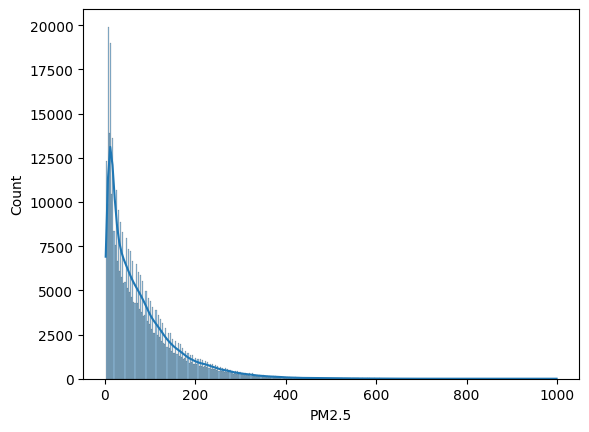

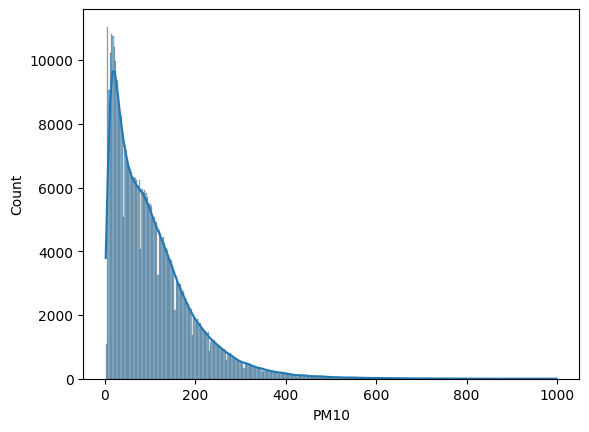

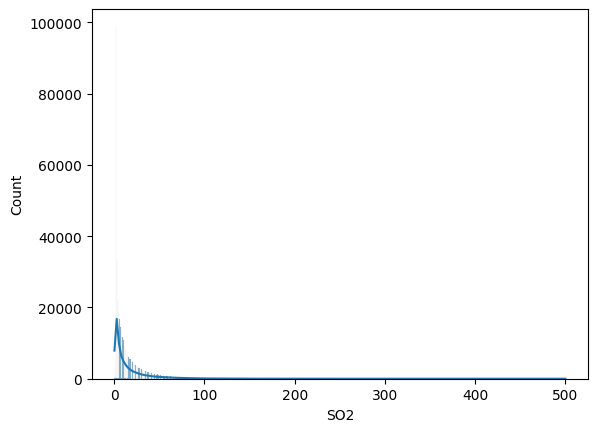

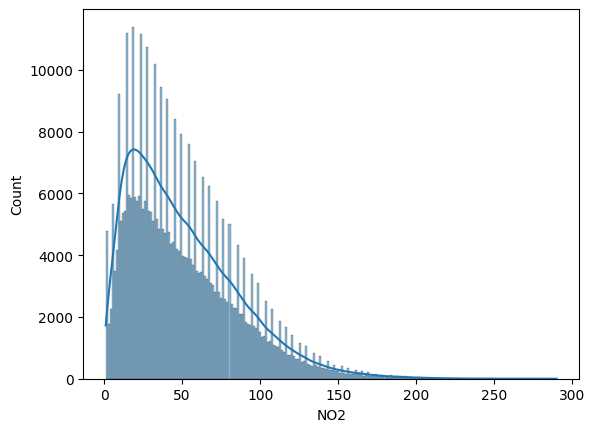

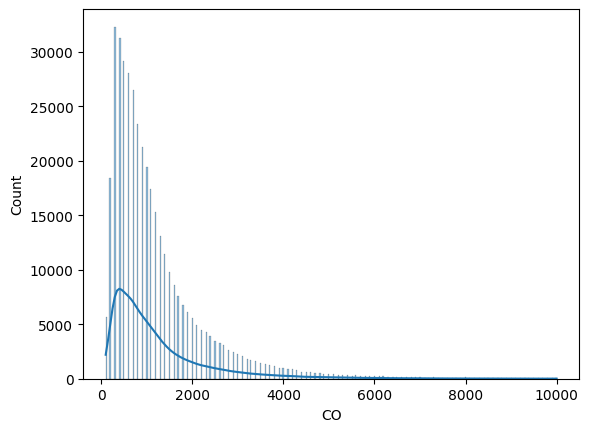

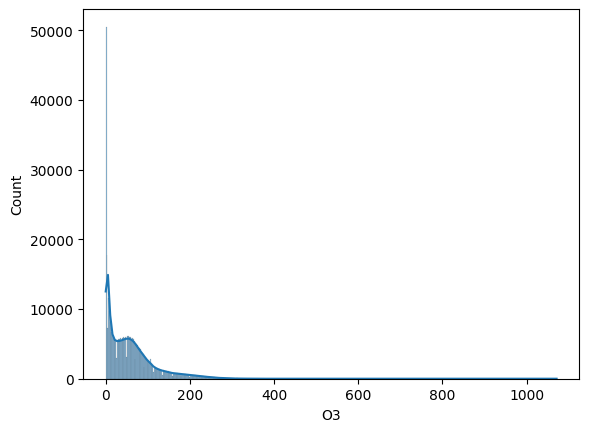

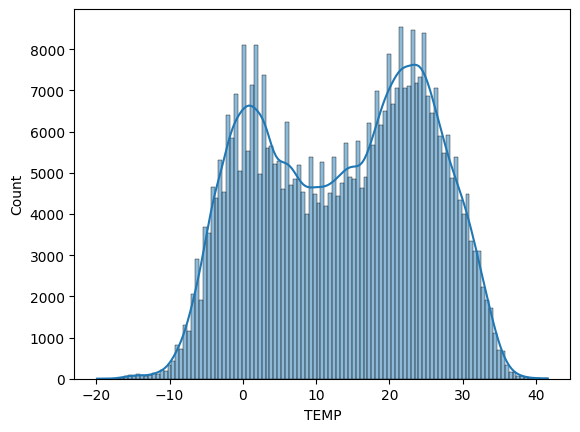

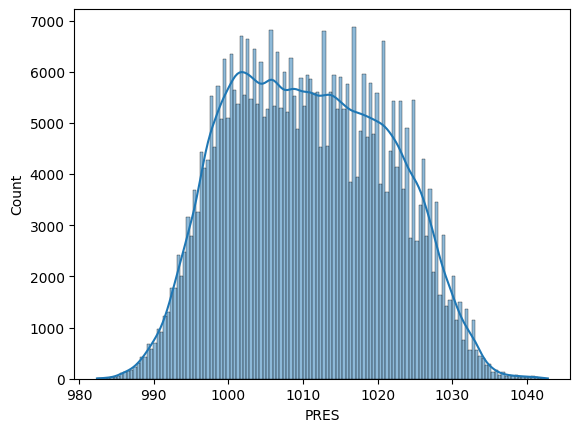

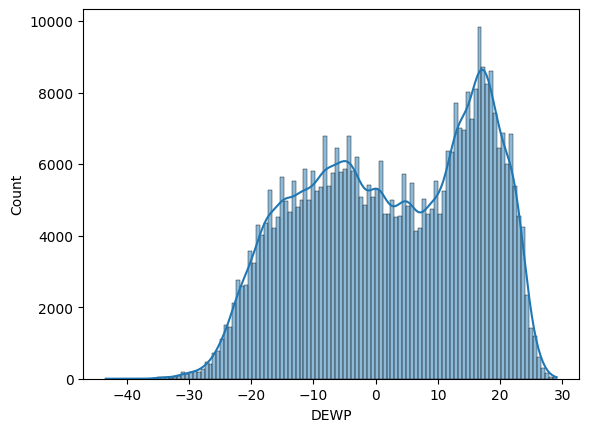

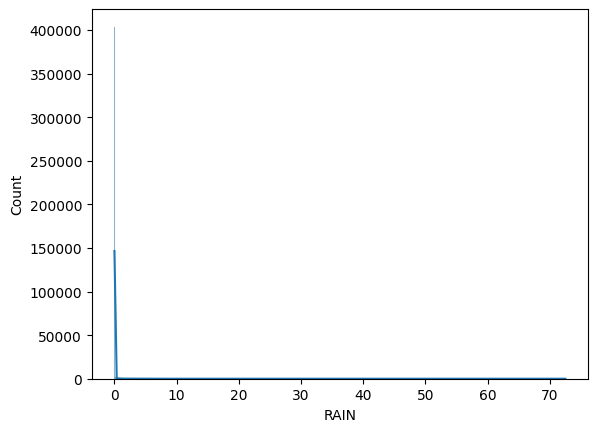

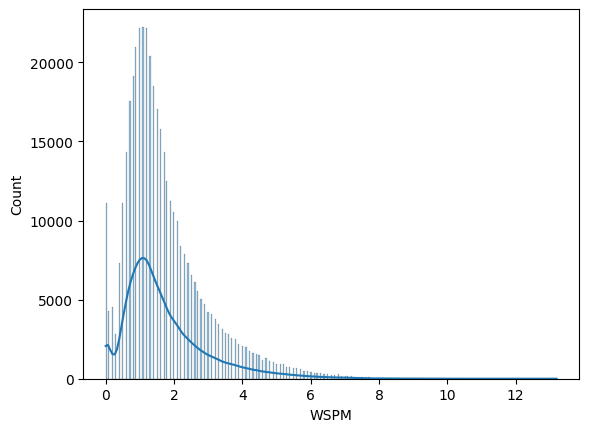

In [101]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde = True)
    plt.show()

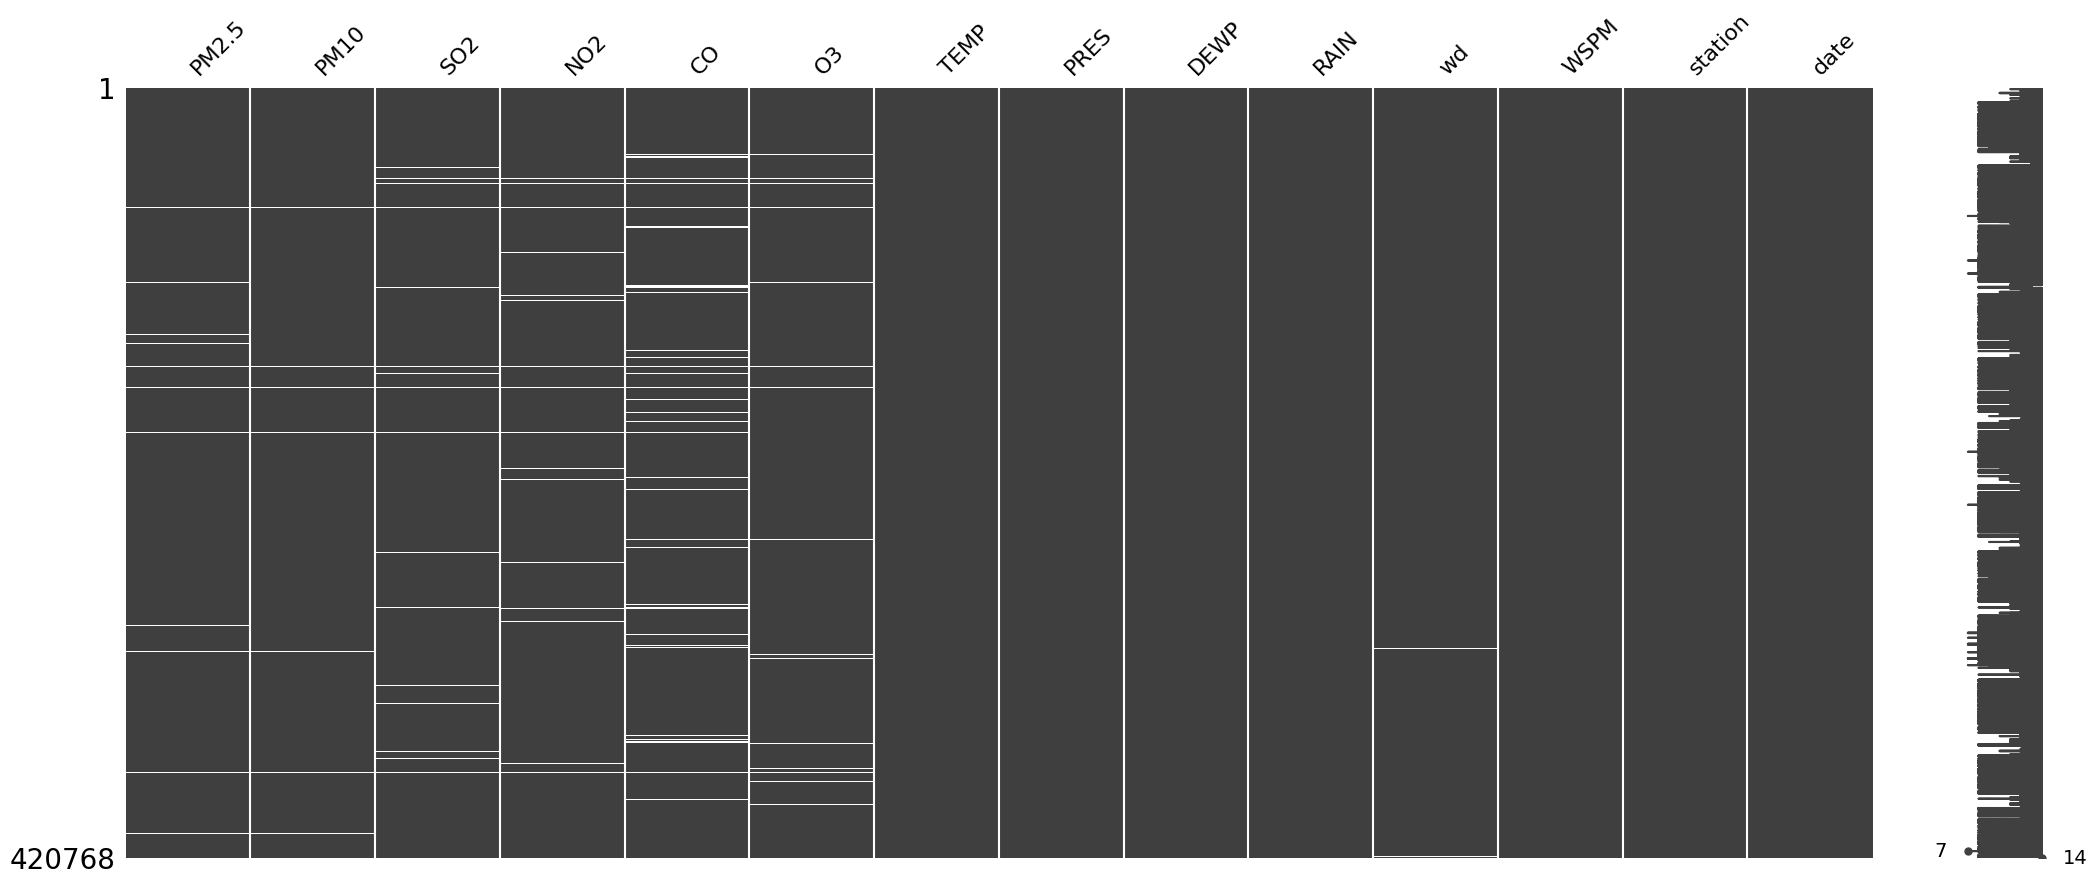

In [102]:
mnso.matrix(df)
plt.show()

In [103]:
df.isnull().sum() /len(df) * 100

PM2.5      2.076916
PM10       1.532674
SO2        2.143937
NO2        2.879497
CO         4.919813
O3         3.155421
TEMP       0.094589
PRES       0.093401
DEWP       0.095777
RAIN       0.092688
wd         0.433018
WSPM       0.075576
station    0.000000
date       0.000000
dtype: float64

In [104]:
missing_values_n = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO','O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
missing_values_s = ['wd','station']
for missing in missing_values_n:
    df[missing] = df[missing].fillna(df[missing].median())
for missing in missing_values_s:
    df[missing] = df[missing].fillna(df[missing].mode()[0])

In [105]:
df.isnull().sum()/len(df) * 100

PM2.5      0.0
PM10       0.0
SO2        0.0
NO2        0.0
CO         0.0
O3         0.0
TEMP       0.0
PRES       0.0
DEWP       0.0
RAIN       0.0
wd         0.0
WSPM       0.0
station    0.0
date       0.0
dtype: float64

In [106]:
df['RAIN'].value_counts()

RAIN
0.0     404248
0.1       3722
0.2       1841
0.3       1382
0.4        907
         ...  
22.2         1
16.6         1
19.8         1
23.8         1
22.4         1
Name: count, Length: 253, dtype: int64

In [107]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 14 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   PM2.5    420768 non-null  float64       
 1   PM10     420768 non-null  float64       
 2   SO2      420768 non-null  float64       
 3   NO2      420768 non-null  float64       
 4   CO       420768 non-null  float64       
 5   O3       420768 non-null  float64       
 6   TEMP     420768 non-null  float64       
 7   PRES     420768 non-null  float64       
 8   DEWP     420768 non-null  float64       
 9   RAIN     420768 non-null  float64       
 10  wd       420768 non-null  str           
 11  WSPM     420768 non-null  float64       
 12  station  420768 non-null  str           
 13  date     420768 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(11), str(2)
memory usage: 44.9 MB


In [108]:
df.set_index('date', inplace =True)

In [109]:
df.head()

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
date,,,,,,,,,,,,,
2013-03-01 00:00:00,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
2013-03-01 01:00:00,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2013-03-01 02:00:00,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
2013-03-01 03:00:00,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
2013-03-01 04:00:00,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


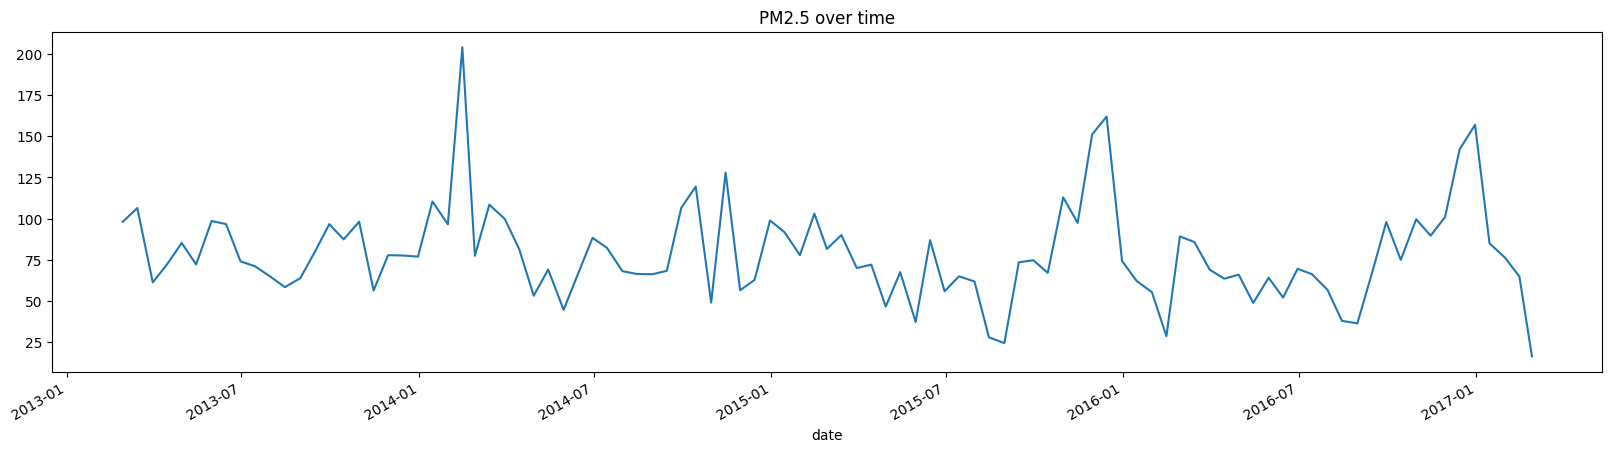

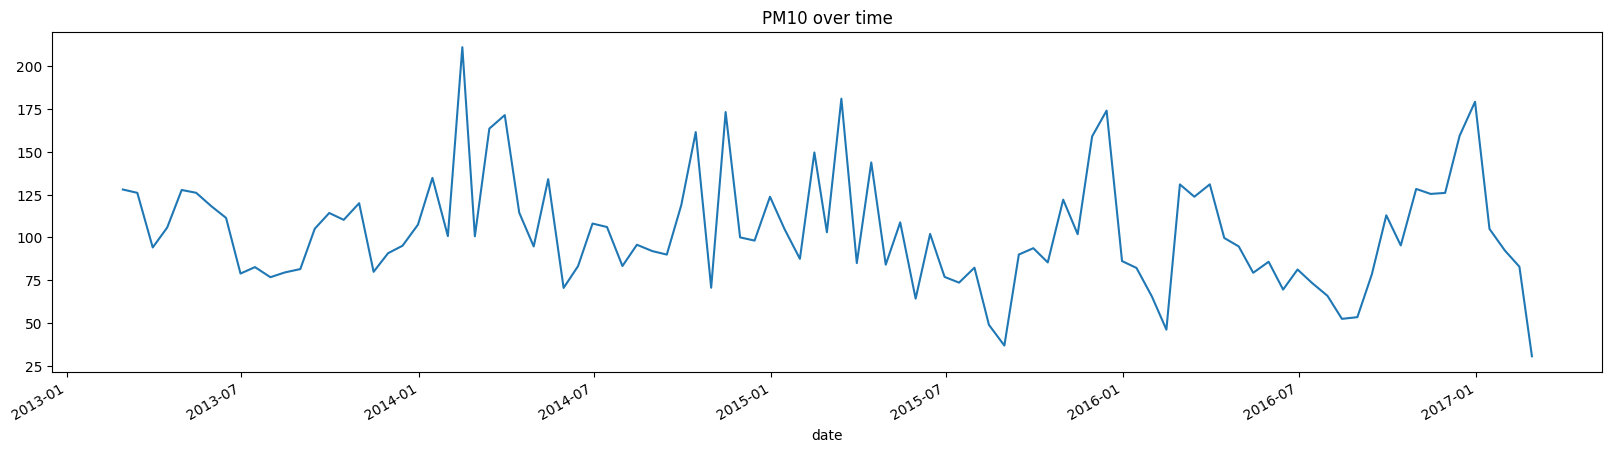

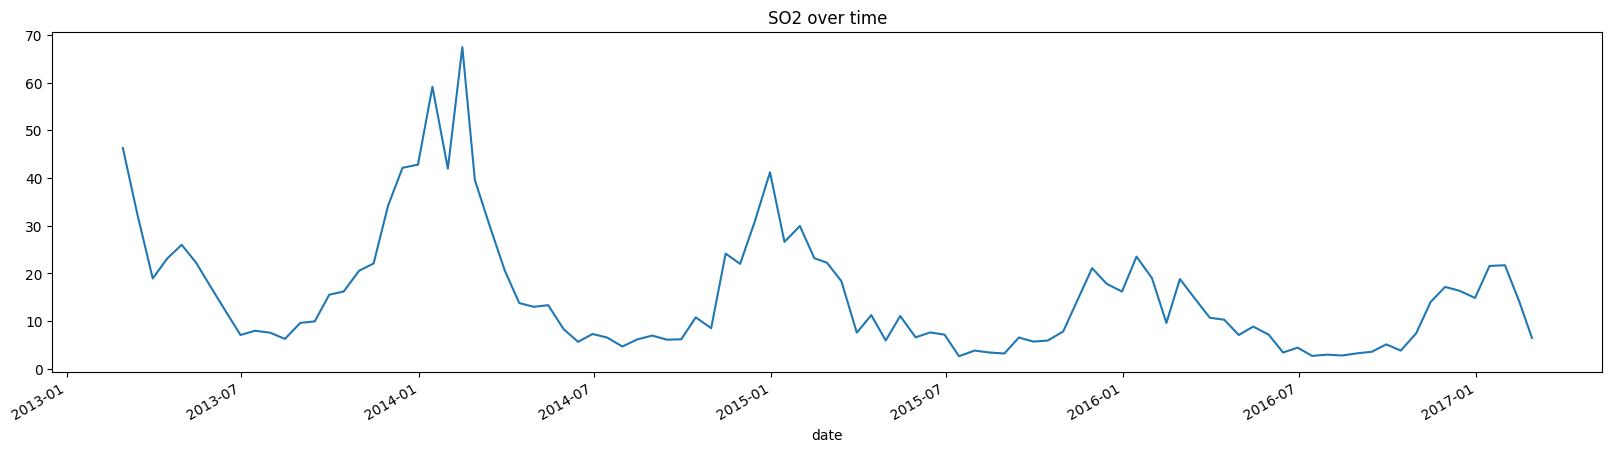

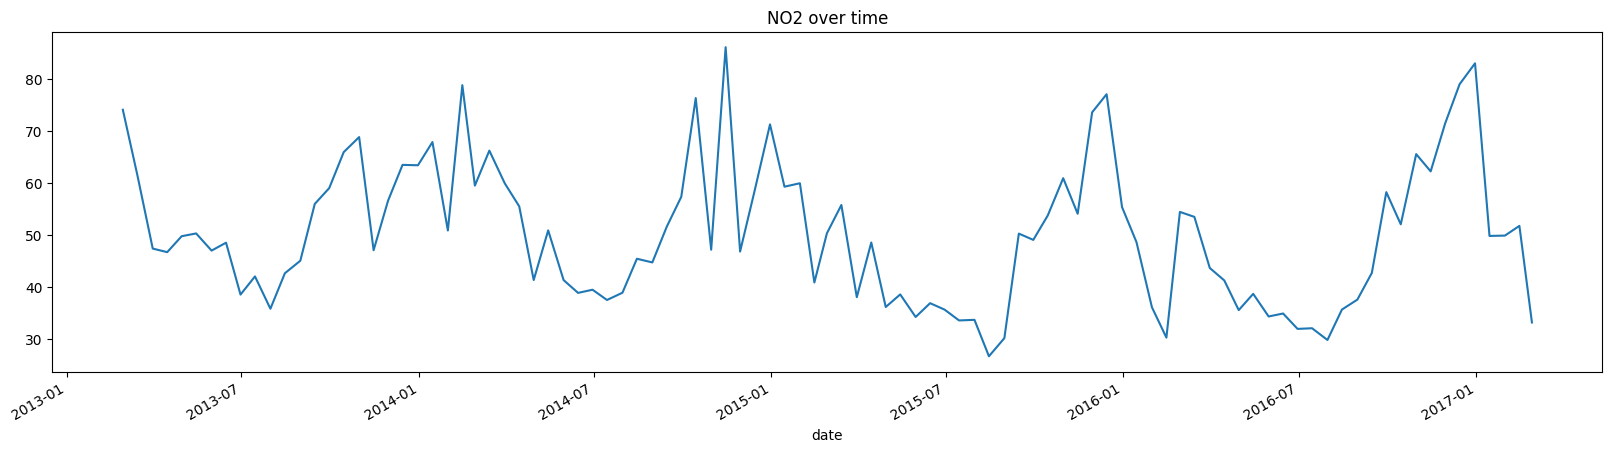

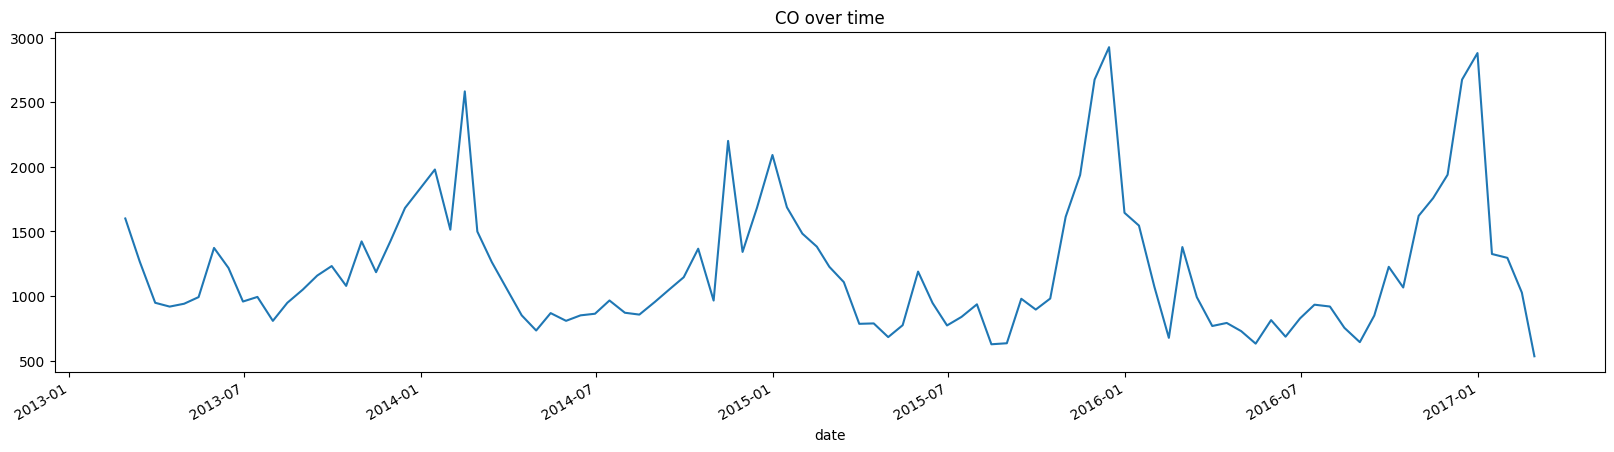

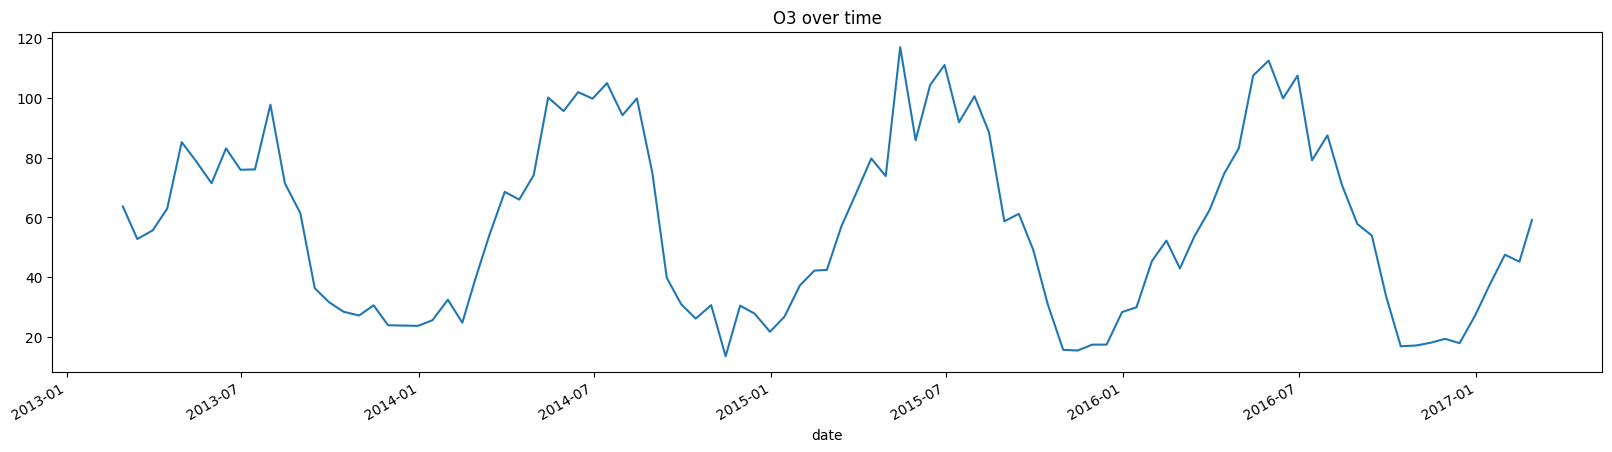

In [110]:
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO','O3']
for pollutant in pollutants:
    df_2 = df[[pollutant]].resample('SME').mean().copy()
    df_2[pollutant].plot(title=f"{pollutant} over time", figsize=(20, 5))
    plt.show()

In [111]:
df_3 = df[['PM2.5']].copy()

In [112]:
df_3 = df_3.resample('SME').mean()

In [113]:
df_3.head()

,PM2.5
date,
2013-02-28,98.132440
2013-03-15,106.455078
2013-03-31,61.329167
2013-04-15,72.377083
2013-04-30,85.279630


In [114]:
size = int(len(df_3)*0.8)

In [115]:
df_train = df_3.iloc[:size]

In [116]:
df_test = df_3.iloc[size:]

In [117]:
sts.adfuller(df_train['PM2.5'])

(np.float64(-4.4477436412558085),
 np.float64(0.00024411281338148846),
 3,
 73,
 {'1%': np.float64(-3.5232835753964475),
  '5%': np.float64(-2.902030597326081),
  '10%': np.float64(-2.5883710883843123)},
 np.float64(615.2290356890379))

In [129]:
print(df_train.index.freq)

<SemiMonthEnd: day_of_month=15>


In [ ]:

print(df_train.isnull().sum())

PM2.5    0
dtype: int64


In [133]:
df_train_copy = df_train.asfreq('ME').copy()

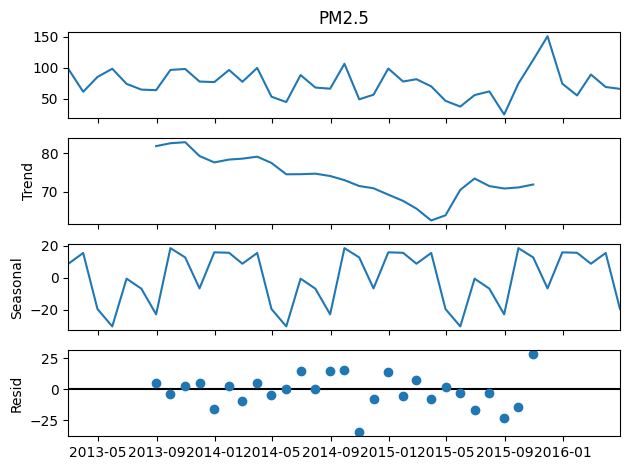

In [134]:
s_dec_additive = seasonal_decompose(df_train_copy['PM2.5'], model='additive')
s_dec_additive.plot()
plt.show()

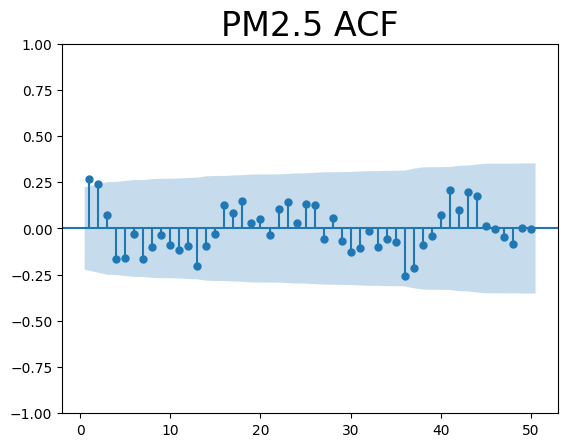

In [124]:
sgt.plot_acf(df_train['PM2.5'], lags=50, zero=False)
plt.title("PM2.5 ACF", size=24)    
plt.show()

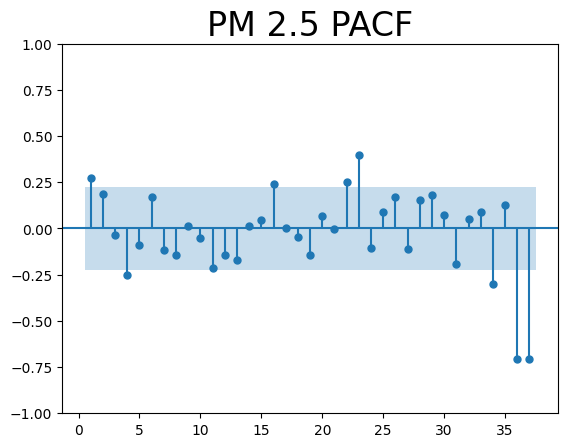

In [127]:
sgt.plot_pacf(df_train['PM2.5'], lags=37, zero=False, method='ols')
plt.title("PM 2.5 PACF", size=24)
plt.show()

In [128]:
model_sarima = SARIMAX(df_train['PM2.5'],
                       order=(1, 1, 1),           
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

results_sarima = model_sarima.fit()
print(results_sarima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              PM2.5   No. Observations:                   77
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -246.531
Date:                            Wed, 27 May 2026   AIC                            503.062
Time:                                    10:37:52   BIC                            512.622
Sample:                                02-28-2013   HQIC                           506.703
                                     - 04-30-2016                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3075      0.141      2.176      0.030       0.030       0.585
ma.L1         -1.0000    619.168   

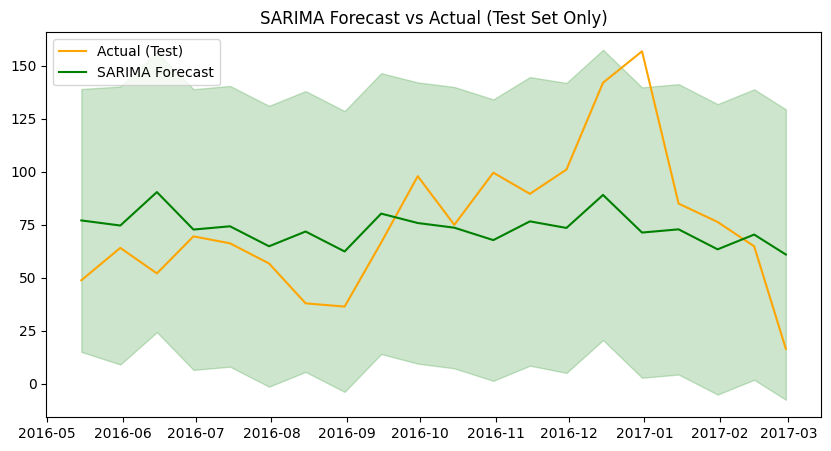

In [135]:
n_steps = len(df_test)
forecast_obj = results_sarima.get_forecast(steps=n_steps)

y_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

plt.figure(figsize=(10,5))
plt.plot(df_test.index, df_test['PM2.5'], label='Actual (Test)', color='orange')
plt.plot(df_test.index, y_pred, label='SARIMA Forecast', color='green')
plt.fill_between(df_test.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='green', alpha=0.2)
plt.title('SARIMA Forecast vs Actual (Test Set Only)')
plt.legend()
plt.show()

In [139]:
y_true = df_test['PM2.5']

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100  

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 23.9742
Root Mean Squared Error (RMSE): 31.1528
Mean Absolute Percentage Error (MAPE): 42.99%


In [141]:
model_arima = ARIMA(df_train['PM2.5'], order=(1,1,1))
results_arima = model_arima.fit()
results_arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  PM2.5   No. Observations:                   77
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -360.759
Date:                Wed, 27 May 2026   AIC                            727.517
Time:                        10:50:51   BIC                            734.510
Sample:                    02-28-2013   HQIC                           730.312
                         - 04-30-2016                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2851      0.089      3.218      0.001       0.111       0.459
ma.L1         -0.9991      1.480     -0.675      0.500      -3.900       1.902
sigma2       740.2807   1093.205      0.677      0.498   -1402.362    2882.924
===================================================================================
Ljung-Box (L1) (Q):                   0.41   Jarque-Bera (JB):                65.50
Prob(Q):                              0.52   Prob(JB):                         0.00
Heteroskedasticity (H):               1.06   Skew:                             1.31
Prob(H) (two-sided):                  0.89   Kurtosis:                         6.71
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [142]:
n_steps = len(df_test)
forecast_obj = results_arima.get_forecast(steps=n_steps)

y_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

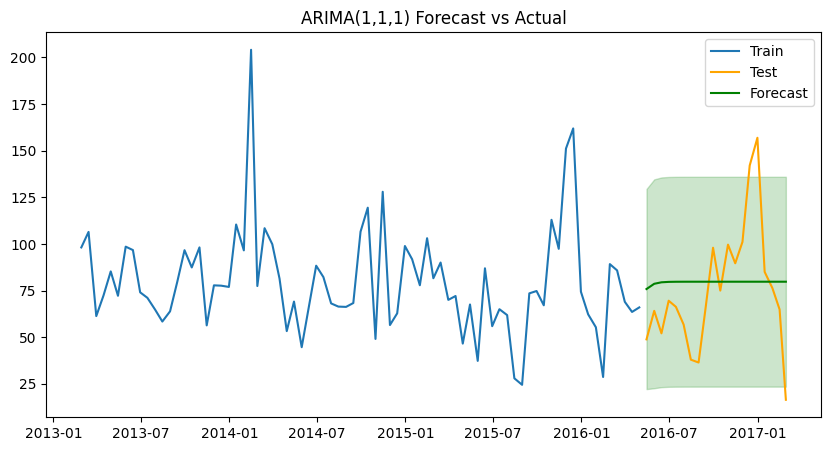

In [146]:
plt.figure(figsize=(10,5))
plt.plot(df_train.index, df_train['PM2.5'], label='Train')
plt.plot(df_test.index, df_test['PM2.5'], label='Test', color='orange')
plt.plot(y_pred.index, y_pred, label='Forecast', color='green')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='green', alpha=0.2)
plt.legend()
plt.title('ARIMA(1,1,1) Forecast vs Actual')
plt.show()

In [149]:
mae = mean_absolute_error(df_test['PM2.5'], y_pred)
rmse = np.sqrt(mean_squared_error(df_test['PM2.5'], y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100 

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

MAE : 25.69
RMSE: 32.93
Mean Absolute Percentage Error (MAPE): 52.10%
